# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. We use general linear models because they model dependent variables that aren't just normal distributions. The benefit of this model is that it allows models to learn non-linear patterns. Its overall flexibility gives it an advantage over linear models because it doesn't just include a straight line, but also non-linear interactions.
2.  Binary and categorical cross entropy are effective loss functions because the function itself is derived from the maximum likelihood estimation and the model gets adjusted more heavily when it makes a wrong prediction that it thinks is right.
3. True, the formula is a linear combination of inputs (no polynomials).
4. False, logistic regression can be used for binary classification.
5. No the coefficient does not. It represents the change in the log odds for a one unit change in X.
6. False, because the relationship between the features and log odds is linear. Logistic regression doesn't instantly capture polynomial relationships and feature engineering helps capture the patterns.
7. False, logistic regression is helpful for some things, but there are also other efficient tools for other things. Logsitic regression is used for categorical variables while OLS is used when the target variable is continuous.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [15]:
# Question 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv('./data/data.csv', sep=';')
cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 
        'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = df[cols].copy()
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


There are no missing values in the dataset, so we can proceed with the analysis without needing to handle any NaNs.

In [16]:
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

binary = ['Debtor',
          'Tuition fees up to date',
          'Scholarship holder', 
          'Age at enrollment'
]

X_bin = df[binary]
y_bin = df['dropout']
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


In [ ]:
# Question 2
log_reg = LogisticRegression()
log_reg.fit(X_bin, y_bin)

coef_df = pd.DataFrame(
    {'Variable': X_bin.columns, 'Coefficient': log_reg.coef_[0]}
).sort_values('Coefficient')

print('Logistic Regression Coefficients:', coef_df)

Logistic Regression Coefficients:                   Variable  Coefficient
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925
0                   Debtor     0.530625


The variables that predict higher dropout probability are age at enrollment and debtor. The opposite is true for those who are up to date with tuition fees and are scholarship holders.

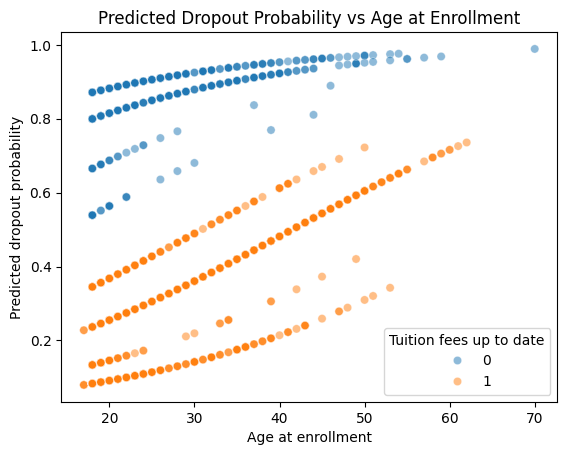

In [18]:
# Question 3 

df['p_dropout_log'] = log_reg.predict_proba(X_bin)[:, 1]
sns.scatterplot(
    data=df, x='Age at enrollment',
    y='p_dropout_log',
    hue='Tuition fees up to date',
    alpha=0.5)

plt.title('Predicted Dropout Probability vs Age at Enrollment')
plt.ylabel('Predicted dropout probability')
plt.legend(title='Tuition fees up to date')
plt.show()

In [19]:
p_up   = df.loc[df["Tuition fees up to date"] == 1, "p_dropout_log"].mean()
p_down = df.loc[df["Tuition fees up to date"] == 0, "p_dropout_log"].mean()
avg_reduction = p_down - p_up
print('Avg reduction in risk when up to date:', avg_reduction)

Avg reduction in risk when up to date: 0.6125849339965014


The most dramatic reduction in the probability of dropout is for younger and middle-aged students. Being up to date on tuition decreased probability by about 61.3%.

In [20]:
# Question 4

y_pred_log = log_reg.predict(X_bin)
cm_log = confusion_matrix(y_bin, y_pred_log)
acc_log = accuracy_score(y_bin, y_pred_log)

print('Logistic regression accuracy:', acc_log)
print('Confusion matrix:\n', cm_log)

Logistic regression accuracy: 0.7619801084990958
Confusion matrix:
 [[2841  162]
 [ 891  530]]


The accuracy of logistic regression is about 76.2%.

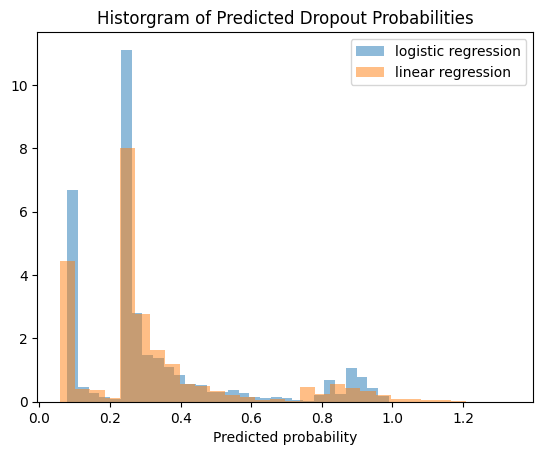

In [21]:
# Question 5

lin_reg = LinearRegression()
lin_reg.fit(X_bin, y_bin)

df['p_dropout_lin'] = lin_reg.predict(X_bin)

plt.hist(df['p_dropout_log'], bins=30, alpha=0.5, label='logistic regression', density=True)
plt.hist(df['p_dropout_lin'], bins=30, alpha=0.5, label='linear regression', density=True)
plt.xlabel('Predicted probability')
plt.title('Historgram of Predicted Dropout Probabilities')
plt.legend()
plt.show()

Question 6: Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

The students most at-risk of dropping out are ones who are in debt, don't have a scholarship, are older, and aren't up to date with their tutition payments. Some resources that would act as interventions for them are payment plans, more scholarships, and more advising to help them stay enrolled and pay their tuition.

In [22]:
# Question 7 

multi = [
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)",
]
X_multi = df[multi]
y_multi = df["Target"]

multi_log_reg = LogisticRegression(solver='lbfgs', max_iter=1000)
multi_log_reg.fit(X_multi, y_multi)

y_pred_multi = multi_log_reg.predict(X_multi)
cm_multi = confusion_matrix(y_multi, y_pred_multi, labels=multi_log_reg.classes_)
print('Multinomial logistic regression confusion matrix:\n', cm_multi)

Multinomial logistic regression confusion matrix:
 [[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


This matrix shows that the model correctly classified 1054 dropouts and 2063 graduates, and 794 students were misclassified.

In [23]:
unique_pred_hard = np.unique(y_pred_multi)
y_prob_multi = multi_log_reg.predict_proba(X_multi)
soft_highest = multi_log_reg.classes_[np.unique(np.argmax(y_prob_multi, axis=1))]

print('Hard predictions (unique):', unique_pred_hard)
print('Classes with the highest soft probability:', soft_highest)

Hard predictions (unique): ['Dropout' 'Graduate']
Classes with the highest soft probability: ['Dropout' 'Graduate']


The hard classification model only gives the classifications of Dropout or Graduate, which means that students who are currently enrolled get misclassified. Meanwhile, the soft classification model does classify students as enrolled, but their probability isn't the highest. This means that the variables we have are good predictors of if a person will drop out or not, but not a good predictor for knowing whether they are enrolled. 

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [27]:
# Question 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import statsmodels.api as sm

df = pd.read_csv('./data/cirrhosis.csv')

COLS = ['Status', 'Drug', 'Bilirubin', 'Edema', 'Stage']
df = df[COLS]
df.isna().sum()

Status         0
Drug         106
Bilirubin      0
Edema          0
Stage          6
dtype: int64

In [28]:
df = df.dropna(subset=['Drug'])
df.head()

,Status,Drug,Bilirubin,Edema,Stage
0,D,D-penicillamine,14.5,Y,4.0
1,C,D-penicillamine,1.1,N,3.0
2,D,D-penicillamine,1.4,S,4.0
3,D,D-penicillamine,1.8,S,4.0
4,CL,Placebo,3.4,N,3.0


Because the drug feature has 106 missing values, I dropped those rows. I used .dropna() to do this.

In [29]:
# Question 2
df['Status_Binary'] = df['Status'].map({'C': 1, 'CL': 1, 'D': 0}).astype(float)
df['Drug_Binary'] = df['Drug'].map({'D-penicillamine': 1, 'Placebo': 0}).astype(float)

edema_dummies = pd.get_dummies(df['Edema'], prefix='Edema').astype(float)
df_reg = pd.concat([df, edema_dummies], axis=1)

feature_cols = ['Drug_Binary', 'Bilirubin', 'Edema_S', 'Edema_Y']
X = df_reg[feature_cols].astype(float)
X_sm = sm.add_constant(X)
y = df_reg['Status_Binary']

log = sm.Logit(y, X_sm).fit(disp=0)
print('Logistic regression summary (Survival):\n', log.summary())


Logistic regression summary (Survival):
                            Logit Regression Results                           
Dep. Variable:          Status_Binary   No. Observations:                  312
Model:                          Logit   Df Residuals:                      307
Method:                           MLE   Df Model:                            4
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.2119
Time:                        21:11:43   Log-Likelihood:                -165.55
converged:                       True   LL-Null:                       -210.06
Covariance Type:            nonrobust   LLR p-value:                 2.117e-18
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.6614      0.254      6.549      0.000       1.164       2.159
Drug_Binary    -0.2527      0.269     -0.938      0.348      -0.781       0.275
Bilirub

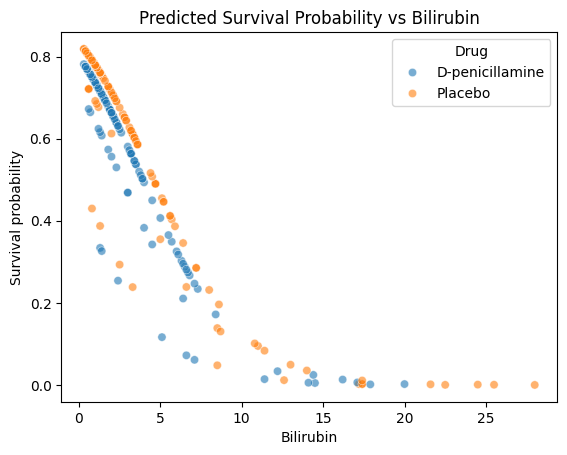

In [30]:
# Question 3

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X, y)
df_reg['pred_proba_logit'] = log_reg.predict_proba(X)[:, 1]

sns.scatterplot(data=df_reg, x='Bilirubin', y='pred_proba_logit', hue='Drug', alpha=0.6)
plt.title('Predicted Survival Probability vs Bilirubin')
plt.ylabel('Survival probability')
plt.show()

In [31]:
avg_drug = df_reg[df_reg['Drug_Binary'] == 1]['pred_proba_logit'].mean()
avg_placebo = df_reg[df_reg['Drug_Binary'] == 0]['pred_proba_logit'].mean()

print('Drug survival rate (avg):', avg_drug)
print('Placebo survival rate (avg):', avg_placebo)

Drug survival rate (avg): 0.5899901364370074
Placebo survival rate (avg): 0.6089710160436076


The scatter plot shows us that the lower Bilirubin values increases the patient's survival rate for the drug. On average, patients who took the drug had a 59% chance of survival and those who took the placebo has a 60.9%. This means that the drug deacreased survival by 1.9%.

In [32]:
# Question 4

df_reg['pred_label_logit'] = log_reg.predict(X)
cm_log = confusion_matrix(y, df_reg['pred_label_logit'])
acc_log = accuracy_score(y, df_reg['pred_label_logit'])

print('Accuracy:', acc_log)
print('Confusion matrix:\n', cm_log)

Accuracy: 0.7371794871794872
Confusion matrix:
 [[ 59  66]
 [ 16 171]]


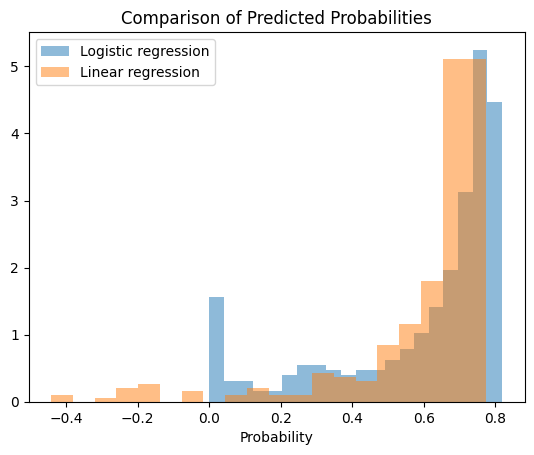

In [33]:
# Question 5

lin_reg = LinearRegression()
lin_reg.fit(X, y)
df_reg['pred_proba_lin'] = lin_reg.predict(X)
plt.hist(df_reg['pred_proba_logit'], bins=20, alpha=0.5, label='Logistic regression', density=True)
plt.hist(df_reg['pred_proba_lin'], bins=20, alpha=0.5, label='Linear regression', density=True)
plt.title('Comparison of Predicted Probabilities')
plt.xlabel('Probability')
plt.legend()
plt.show()

This histogram shows us that the logistic regression predicts normal probabilties between 0 and 1. Meanwhile, the linear model predicts negative probabilities, which isn't possible. Therefore, we can conclude that the logistic regression model is the best predictor here.

In [34]:
df_stage = df_reg.dropna(subset=['Stage']).copy()
X_stage = df_stage[['Bilirubin', 'Edema_S', 'Edema_Y']].astype(float)
y_stage = df_stage['Stage'].astype(int)

stage_log = LogisticRegression(max_iter=1000)
stage_log.fit(X_stage, y_stage)
df_stage['pred_stage'] = stage_log.predict(X_stage)
stage_probs = stage_log.predict_proba(X_stage)

cm_stage = confusion_matrix(y_stage, df_stage['pred_stage'])
df_stage_probs = pd.DataFrame(stage_probs, columns=stage_log.classes_)

print('Confusion matrix (stage):\n', cm_stage)
print('\nStages predicted:', np.unique(df_stage['pred_stage']))
print('\nMin/max  probability for each stage:\n', df_stage_probs.agg(['min', 'max']))

Confusion matrix (stage):
 [[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]

Stages predicted: [3 4]

Min/max  probability for each stage:
                 1         2         3         4
min  2.982598e-09  0.012899  0.104528  0.255662
max  1.100461e-01  0.255032  0.428496  0.882573


Does your hard classification predict every class? Do your predicted probabilities predict every class?

In the hard classification, the model predicted stage 3 and 4, but not 1 or 2 for any patient. Predicted probabilities predicted every class. Stll, stages 1 and 2 didn't ever have the highest probabilties. It is possible that, because high levels of Bilirubin and Edema tend to show up in later stages, the model wasn't able to clearly distinguish between the early and later stagers.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

The answers are included in the other link because this was giving too many problems.